# Heart Disease Prediction - Model Inference
## MLOps Assignment 1

This notebook demonstrates:
- Loading trained models
- Making predictions on new data
- Model interpretation
- API usage examples

In [8]:
# Import required libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import requests
import json

from src.models.predictor import HeartDiseasePredictor

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Load Trained Model

In [9]:
# Initialize predictor with best model
predictor = HeartDiseasePredictor(
    model_path='../models/random_forest.pkl',
    preprocessor_path='../models/preprocessor.pkl'
)

print('✓ Model loaded successfully!')
print(f'Model type: {type(predictor.model).__name__}')
print(f'Features: {predictor.feature_names}')

INFO:src.models.predictor:Loading model from ../models/random_forest.pkl
/opt/homebrew/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
INFO:src.models.predictor:Loading preprocessor from ../models/preprocessor.pkl
/opt/homebrew/lib/python3.13/site-packag

✓ Model loaded successfully!
Model type: RandomForestClassifier
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 2. Single Prediction Example

In [10]:
# Example patient data
patient_1 = {
    'age': 63,
    'sex': 1,          # Male
    'cp': 3,           # Typical angina
    'trestbps': 145,   # Resting blood pressure
    'chol': 233,       # Cholesterol
    'fbs': 1,          # Fasting blood sugar > 120 mg/dl
    'restecg': 0,      # Normal ECG
    'thalach': 150,    # Max heart rate
    'exang': 0,        # No exercise induced angina
    'oldpeak': 2.3,    # ST depression
    'slope': 0,        # Upsloping
    'ca': 0,           # 0 major vessels
    'thal': 1          # Fixed defect
}

# Make prediction
result = predictor.predict_proba(patient_1)

print("Prediction Results:")
print("=" * 50)
print(f"Prediction: {'Disease' if result['prediction'] == 1 else 'No Disease'}")
print(f"Probability of No Disease: {result['probability_no_disease']:.2%}")
print(f"Probability of Disease: {result['probability_disease']:.2%}")
print(f"Confidence: {result['confidence']:.2%}")
print(f"Risk Level: {result['risk_level']}")

Prediction Results:
Prediction: No Disease
Probability of No Disease: 73.11%
Probability of Disease: 26.89%
Confidence: 73.11%
Risk Level: Low


## 3. Batch Predictions

In [11]:
# Multiple patients
patients = [
    {
        'age': 45, 'sex': 0, 'cp': 1, 'trestbps': 120,
        'chol': 200, 'fbs': 0, 'restecg': 0, 'thalach': 170,
        'exang': 0, 'oldpeak': 0.5, 'slope': 1, 'ca': 0, 'thal': 2
    },
    {
        'age': 67, 'sex': 1, 'cp': 3, 'trestbps': 160,
        'chol': 286, 'fbs': 1, 'restecg': 1, 'thalach': 108,
        'exang': 1, 'oldpeak': 1.5, 'slope': 0, 'ca': 3, 'thal': 2
    },
    {
        'age': 55, 'sex': 0, 'cp': 0, 'trestbps': 130,
        'chol': 220, 'fbs': 0, 'restecg': 0, 'thalach': 150,
        'exang': 0, 'oldpeak': 0.0, 'slope': 1, 'ca': 0, 'thal': 2
    }
]

# Batch prediction
batch_results = predictor.predict_batch(patients)

# Display results
results_df = pd.DataFrame(batch_results)
results_df['prediction_label'] = results_df['prediction'].map({0: 'No Disease', 1: 'Disease'})

print("Batch Prediction Results:")
print(results_df[['prediction_label', 'probability_disease', 'risk_level', 'confidence']])

Batch Prediction Results:
  prediction_label  probability_disease risk_level  confidence
0       No Disease             0.029857        Low    0.970143
1          Disease             0.597739   Moderate    0.597739
2       No Disease             0.114254        Low    0.885746


## 4. API Testing (if API is running)

In [12]:
# Test if API is running
API_URL = "http://localhost:8000"

try:
    response = requests.get(f"{API_URL}/health", timeout=5)
    print("API Status:", response.json())
    api_available = True
except:
    print("API is not running. Start it with: python src/api/app.py")
    api_available = False

API is not running. Start it with: python src/api/app.py


In [13]:
# Make prediction via API
if api_available:
    response = requests.post(
        f"{API_URL}/predict",
        json=patient_1
    )
    
    if response.status_code == 200:
        result = response.json()
        print("\nAPI Prediction Result:")
        print(json.dumps(result, indent=2))
    else:
        print(f"Error: {response.status_code}")
        print(response.text)

## 5. Feature Importance Analysis

/var/folders/wm/yqjqbf854lxgtxlqyj6318dr0000gn/T/ipykernel_74007/2581826535.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')


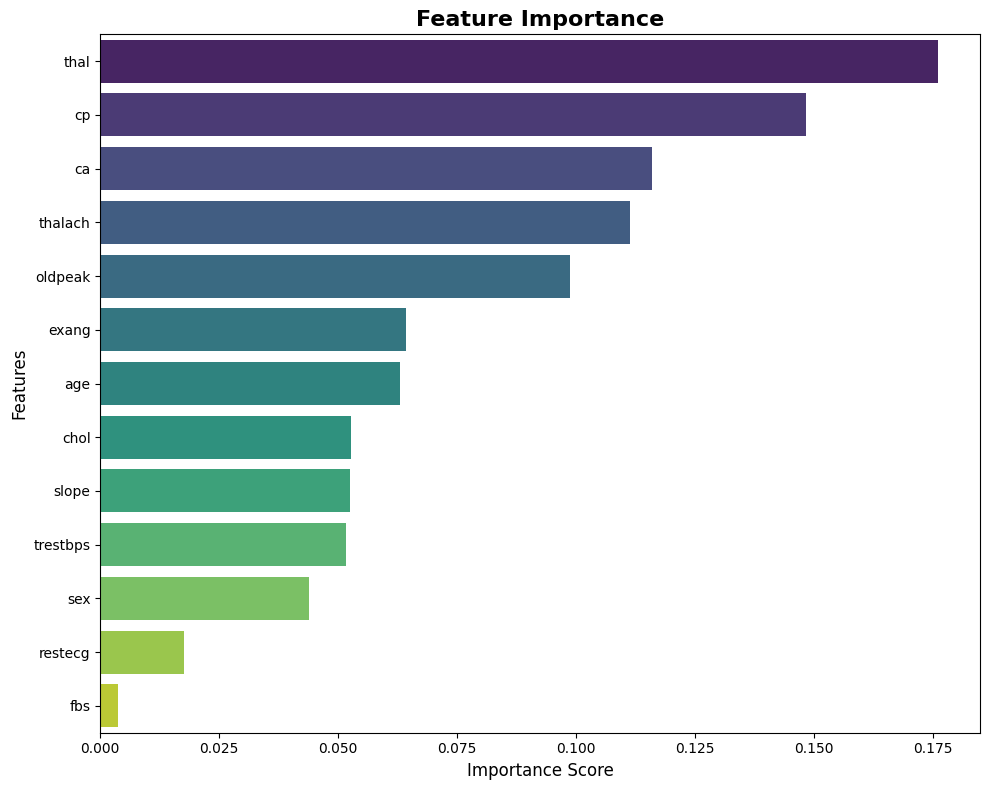


Top 5 Most Important Features:
    feature  importance
12     thal    0.176158
2        cp    0.148378
11       ca    0.116056
7   thalach    0.111433
9   oldpeak    0.098690


In [14]:
# Get feature importance (if model supports it)
if hasattr(predictor.model, 'feature_importances_'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    feature_importance = pd.DataFrame({
        'feature': predictor.feature_names,
        'importance': predictor.model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
    plt.title('Feature Importance', fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.savefig('../screenshots/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nTop 5 Most Important Features:")
    print(feature_importance.head())
else:
    print("Model does not support feature importance analysis")

## Summary

This notebook demonstrated:
- ✅ Loading trained models for inference
- ✅ Making single and batch predictions
- ✅ Using the prediction API
- ✅ Analyzing feature importance

The model is ready for production deployment!